QUESTION 3: Data Loading and Augmentation Using PyTorch

📁 Creating sample dataset...
✅ Sample dataset created!

Task 1: Define transformation pipeline
✅ Transform pipeline defined:
  - Resize: 64x64
  - RandomHorizontalFlip: p=0.5
  - RandomVerticalFlip: p=0.2
  - RandomRotation: 45 degrees
  - ToTensor

Task 2: Load dataset using ImageFolder
✅ Dataset loaded: 45 samples

Task 3: Print class names and indices
Class names: ['class_0_non_agri', 'class_1_agri']
Class to index: {'class_0_non_agri': 0, 'class_1_agri': 1}

Task 4: Retrieve image shapes from a batch
Batch image shape: torch.Size([8, 3, 64, 64])
Batch labels: tensor([1, 0, 1, 1, 1, 1, 0, 1])

Task 5: Display images in the custom loader batch


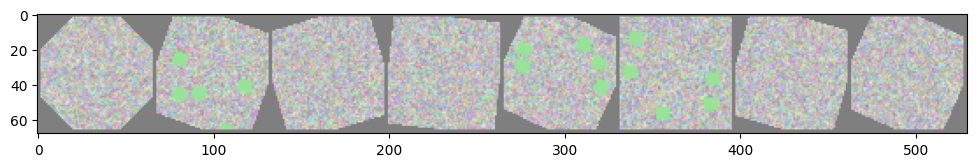

Labels: [0, 1, 0, 0, 1, 1, 0, 0]

✅ QUESTION 3 COMPLETED SUCCESSFULLY!


In [1]:
# ============================================
# QUESTION 3: Data Loading and Augmentation Using PyTorch
# COMPLETE SELF-CONTAINED COLAB NOTEBOOK
# ============================================

import os
import numpy as np
import random
import cv2
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision
import matplotlib.pyplot as plt

print("="*60)
print("QUESTION 3: Data Loading and Augmentation Using PyTorch")
print("="*60)

# ============================================
# STEP 1: Create sample dataset
# ============================================

print("\n📁 Creating sample dataset...")

def create_sample_dataset():
    os.makedirs('./images_dataSAT/class_0_non_agri/', exist_ok=True)
    os.makedirs('./images_dataSAT/class_1_agri/', exist_ok=True)

    for i in range(20):
        img = np.random.randint(0, 255, (84, 80, 3), dtype=np.uint8)
        if i % 2 == 0:
            img[20:60, 30:50] = [200, 200, 200]
        cv2.imwrite(f'./images_dataSAT/class_0_non_agri/non_agri_{i:03d}.png', img)

    for i in range(25):
        img = np.random.randint(0, 255, (84, 80, 3), dtype=np.uint8)
        for _ in range(5):
            x = random.randint(0, 70)
            y = random.randint(0, 74)
            img[y:y+10, x:x+10] = [50, 200, 50]
        cv2.imwrite(f'./images_dataSAT/class_1_agri/agri_{i:03d}.png', img)

    print("✅ Sample dataset created!")

if not os.path.exists('./images_dataSAT'):
    create_sample_dataset()
else:
    print("✅ Dataset already exists!")

# ============================================
# Task 1: Define transformation pipeline
# ============================================

print("\n" + "="*50)
print("Task 1: Define transformation pipeline")
print("="*50)

custom_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=45),
    transforms.ToTensor()
])

print("✅ Transform pipeline defined:")
print(f"  - Resize: 64x64")
print(f"  - RandomHorizontalFlip: p=0.5")
print(f"  - RandomVerticalFlip: p=0.2")
print(f"  - RandomRotation: 45 degrees")
print(f"  - ToTensor")

# ============================================
# Task 2: Load dataset using ImageFolder
# ============================================

print("\n" + "="*50)
print("Task 2: Load dataset using ImageFolder")
print("="*50)

imagefolder_dataset = datasets.ImageFolder(
    root='./images_dataSAT/',
    transform=custom_transform
)

print(f"✅ Dataset loaded: {len(imagefolder_dataset)} samples")

# ============================================
# Task 3: Print class names and indices
# ============================================

print("\n" + "="*50)
print("Task 3: Print class names and indices")
print("="*50)

print(f"Class names: {imagefolder_dataset.classes}")
print(f"Class to index: {imagefolder_dataset.class_to_idx}")

# ============================================
# Task 4: Retrieve and display image shapes from a batch
# ============================================

print("\n" + "="*50)
print("Task 4: Retrieve image shapes from a batch")
print("="*50)

imagefolder_loader = DataLoader(imagefolder_dataset, batch_size=8, shuffle=True)
for images, labels in imagefolder_loader:
    print(f"Batch image shape: {images.shape}")
    print(f"Batch labels: {labels}")
    break

# ============================================
# Task 5: Display images in the custom loader batch
# ============================================

print("\n" + "="*50)
print("Task 5: Display images in the custom loader batch")
print("="*50)

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(imagefolder_loader)
images, labels = next(dataiter)

plt.figure(figsize=(12, 8))
imshow(torchvision.utils.make_grid(images))
print(f'Labels: {labels.tolist()}')

# ============================================
# Summary
# ============================================

print("\n" + "="*50)
print("✅ QUESTION 3 COMPLETED SUCCESSFULLY!")
print("="*50)